# Разведочный анализ данных 

## Предварительная настройка

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
palette = [
    "#264653", 
    "#2a9d8f", 
    "#e9c46a", 
    "#f4a261", 
    "#e76f51", 
    "#8ab17d", 
    "#b5179e"
]

## Постановка задачи

Задача состоит в прогнозировании РТО на февраль для сети магазинов пятерочка. 

Для оценки качества предсказаний будет использоваться функция следующего вида: 

$$
\text{MAPE} = 100*\frac{1}{n}*\sum_{i=1}^n
\lvert 
\frac{y_{\text{pred}_i} - y_{\text{true}_i}}{y_{\text{true}_i}}
\rvert
$$

$$
\text{score} = 100 - \text{min}(\text{MAPE}, 100)
$$

Из описания датасета:

| Название колонки | Тип данных | Описание |
| :--- | :--- | :--- |
| **store_id** | `int64` | Уникальный идентификатор магазина |
| **year** / **month** | `int64` | Год и месяц наблюдения |
| **rto** | `float64` | **Целевая переменная:** Розничный товарооборот за месяц |
| **avg_items** / **avg_promo_items**| `float64` | Среднее кол-во товаров / промо-товаров в одном чеке |
| **avg_cancels** | `float64` | Среднее количество отмен чеков |
| **working_hours** | `float64` | Количество рабочих часов магазина в день |
| **opening_date_cat** | `object` | Категория даты открытия магазина |
| **store_area_cat** | `object` | Категория торговой площади |
| **city** / **region** | `object` | Населенный пункт и регион РФ |
| **population** / **households** | `int64` | Численность населения и кол-во домохозяйств вокруг |
| **foot_traffic** / **car_traffic** | `int64` | Пешеходный и автомобильный трафик в час |
| **marketplaces_100m** | `int64` | Кол-во маркетплейсов, доставок и постаматов в радиусе 100м |
| **pharmacy_300m** / **schools_300m** | `int64` | Кол-во аптек/мед.учреждений и школ в радиусе 300м |
| **stops_300m** | `int64` | Количество остановок общественного транспорта в радиусе 300м |
| **grocery_500m** / **pyaterochka_500m**| `int64` | Кол-во продуктовых конкурентов и других Пятёрочек в радиусе 500м |
| **cash_registers** | `int64` | Количество касс в магазине |
| **alcohol_license** | `int64` | Флаг наличия алкогольной лицензии (0 или 1) |

In [71]:
def get_score(y_true: np.ndarray, predictions: np.ndarray) -> tuple:
    eps_cons = 1e-8
    mape = 100 * np.mean(
        np.abs((predictions - y_true) / np.maximum(y_true, eps_cons))
    )
    score = 100 * ((100 - min(mape, 100)) / 100) ** 2
    return mape, score

In [72]:
rename_dict = {
    "new_id": "store_id",
    "Год": "year",
    "Месяц": "month",
    "Среднее количество промо товаров в чеке": "avg_promo_items",
    "Среднее количество товаров в чеке": "avg_items",
    "Среднее количество отмен": "avg_cancels",
    "Рабочие часы в день": "working_hours",
    "Дата открытия, категориальный": "opening_date_cat",
    "Торговая площадь, категориальный": "store_area_cat",
    "Населенный пункт": "city",
    "Регион": "region",
    "Численность населения": "population",
    "Количество домохозяйств": "households",
    "Трафик пеший, в час": "foot_traffic",
    "Трафик авто, в час": "car_traffic",
    "Маркетплейсы, доставки, постаматы (100 м)": "marketplaces_100m",
    "Медицинские уч. и аптеки (300 м)": "pharmacy_300m",
    "Школы (300 м)": "schools_300m",
    "Остановки (300 м)": "stops_300m",
    "Продуктовые магазины (500 м)": "grocery_500m",
    "Пятерочки (500 м)": "pyaterochka_500m",
    "Количество касс": "cash_registers",
    "Флаг алкогольной лицензии": "alcohol_license",
    "РТО": "rto"
}

## EDA

In [73]:
df = pd.read_csv("train_2.csv")
df = df.rename(columns=rename_dict)
df.sample(5)

,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
6327,280,2024,4,1.32,7.32,92.0,19.0,Средний по возрасту,Большой,Красногорск г,...,183,2,0,0,3,3,0,9,1,7.742345e+07
17409,788,2023,7,1.11,5.64,53.0,8.0,Средний по возрасту,Средний,Красная Горбатка п,...,34,2,0,0,0,0,0,11,1,9.608640e+07
191011,8589,2023,7,1.61,7.25,947.0,12.0,Средний по возрасту,Большой,Сергиев Посад г,...,21,2,1,0,1,9,2,14,1,1.527399e+08
308842,13840,2024,7,0.70,4.78,168.0,17.0,Средний по возрасту,Маленький,Кочубеевское с,...,94,3,0,0,0,2,0,6,1,6.522541e+07
66895,3024,2024,11,0.94,6.33,391.0,13.0,Средний по возрасту,Средний,Якшур-Бодья с,...,1753,1,2,1,0,2,0,10,1,1.180620e+08


In [74]:
print(f"Размер датасета: {df.shape[0]}")
print(f"Количество колонок: {df.shape[1]}")
print(f"Наличие дубликатов: {df.duplicated().any()}\n")
print(f"Наличие пропусков:\n{df.isna().sum().sort_values(ascending=False)}")

Размер датасета: 485082
Количество колонок: 24
Наличие дубликатов: False

Наличие пропусков:
store_id             0
year                 0
month                0
avg_promo_items      0
avg_items            0
avg_cancels          0
working_hours        0
opening_date_cat     0
store_area_cat       0
city                 0
region               0
population           0
households           0
foot_traffic         0
car_traffic          0
marketplaces_100m    0
pharmacy_300m        0
schools_300m         0
stops_300m           0
grocery_500m         0
pyaterochka_500m     0
cash_registers       0
alcohol_license      0
rto                  0
dtype: int64


In [75]:
def get_stats(X):
    uniques = X.nunique()
    return pd.DataFrame({
        "Количество уникальных": uniques,
        "Доля": np.round(uniques / X.shape[0] * 100, 2),
        "Тип данных": X.dtypes
    }).sort_values(by="Доля", ascending=False)

In [76]:
get_stats(df).head(10)

,Количество уникальных,Доля,Тип данных
rto,485070,100.00,float64
store_id,18657,3.85,int64
population,17205,3.55,int64
households,7912,1.63,int64
city,3270,0.67,str
avg_cancels,2792,0.58,float64
car_traffic,1078,0.22,int64
avg_items,998,0.21,float64
foot_traffic,542,0.11,int64
avg_promo_items,279,0.06,float64


### Анализ целевой переменной

In [77]:
df_rto = df["rto"]
df_rto.describe ()

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
max      6.557204e+08
Name: rto, dtype: float64

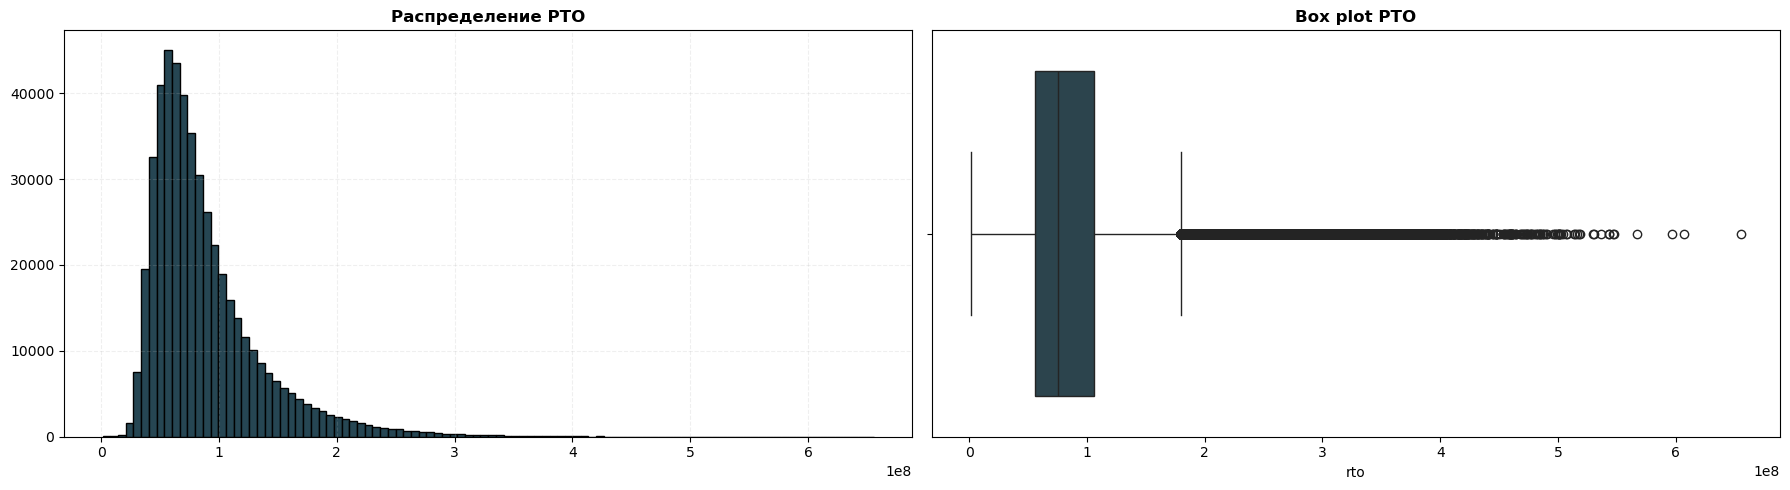

In [78]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

axes[0].hist(
    df_rto,
    bins=100,
    color=palette[0],
    edgecolor="black",
)
axes[0].set_title("Распределение РТО", weight="bold")
axes[0].grid(linestyle="--", alpha=0.2)

sns.boxplot(x=df_rto, color=palette[0], ax=axes[1])
axes[1].set_title("Box plot РТО", weight="bold")

plt.tight_layout()

### Анализ аномально высокой выручки

Изучим топ-1% магазинов по обороту, чтобы понять, что объединяет самые прибыльные точки.

In [79]:
rto_threshold_99 = df["rto"].quantile(0.99)
df_high_rto = df[df["rto"] > rto_threshold_99]

print(f"Порог 99-го квантиля: {np.round(rto_threshold_99, 2)} руб")
print(f"Количество записей в топ-1%: {len(df_high_rto)}")
df_high_rto.sample(3)

Порог 99-го квантиля: 265394753.81 руб
Количество записей в топ-1%: 4851


,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
408355,18284,2024,12,0.87,6.53,1152.0,13.0,Открыт давно,Очень большой,Санкт-Петербург г,...,283,0,2,1,6,2,0,22,1,3.537551e+08
465084,20841,2023,11,1.16,5.83,1080.0,10.0,Новый,Большой,Балашиха г,...,97,7,3,0,0,7,2,18,1,3.036104e+08
176268,7931,2023,7,1.54,9.19,86.0,9.0,Средний по возрасту,Средний,Подмошье д,...,6,4,0,0,1,2,0,14,1,2.683847e+08


Проверим, как выручка в этих магазинах коррелирует с пешеходным трафиком. Это поможет понять, является ли высокий РТО следствием удачного расположения.

In [80]:
print("Топ-5 городов по количеству сверхприбыльных магазинов:")
print(df_high_rto["city"].value_counts().head())
print("\nРаспределение по размеру площади:")
print(df_high_rto["store_area_cat"].value_counts())
print("\nРаспределение по дате открытия:")
print(df_high_rto["opening_date_cat"].value_counts())

Топ-5 городов по количеству сверхприбыльных магазинов:
city
Москва г             1868
Санкт-Петербург г    1189
Балашиха г            114
Домодедово г           81
Раменское г            77
Name: count, dtype: int64

Распределение по размеру площади:
store_area_cat
Очень большой    2324
Большой          2158
Средний           332
Маленький          37
Name: count, dtype: int64

Распределение по дате открытия:
opening_date_cat
Открыт давно           2223
Средний по возрасту    1728
Новый                   900
Name: count, dtype: int64


Попробуем оценить зависимость РТО от трафика - возможно он полностью объясняет успех отдельных магазинов. В противном случае, скорее всего имеет место покупательная способность населения:

Хочу оценить зависимости от следуюзщего - working_hours, households, foot_traffic, grocery_500m. Сделай, перепиши введение.

### Анализ зависимостей для топ-1% магазинов

Оценим, как ключевые количественные показатели влияют на РТО в сегменте сверхприбыльных точек.

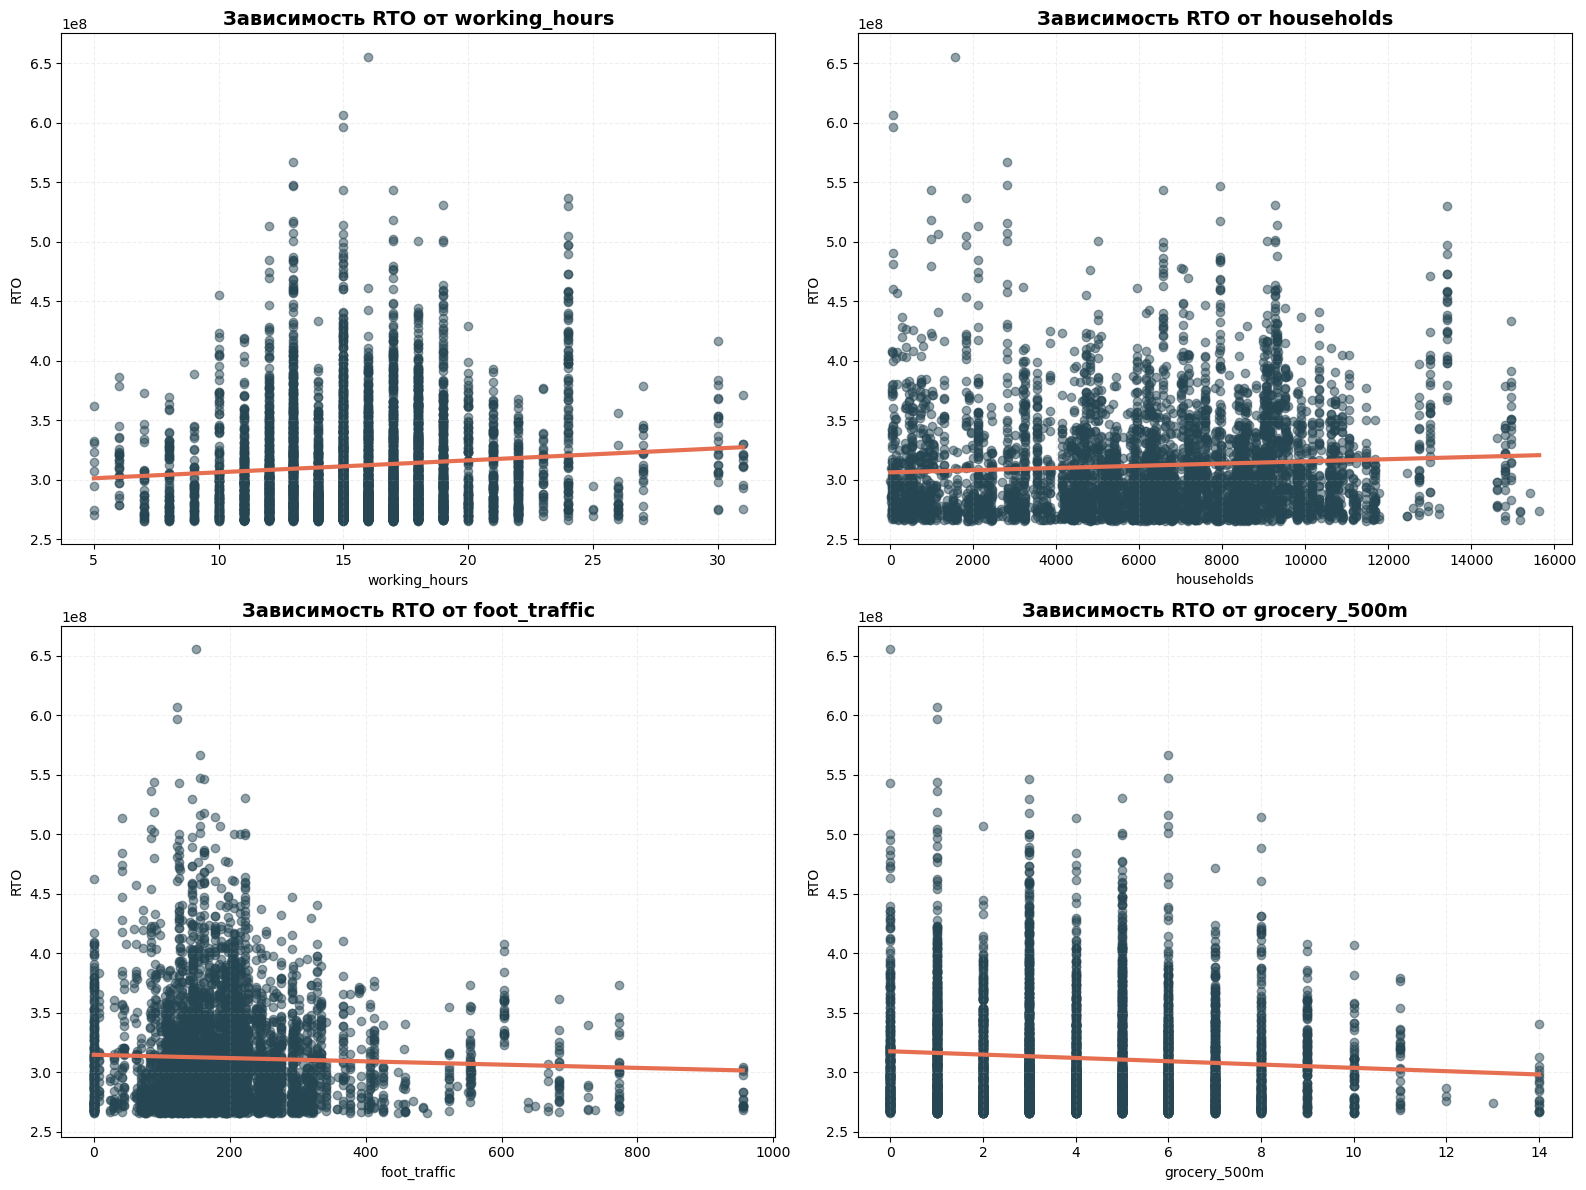

In [81]:
features = ["working_hours", "households", "foot_traffic", "grocery_500m"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(features):
    x = df_high_rto[col]
    y = df_high_rto["rto"]
    axes[i//2][i%2].scatter(x, y, alpha=0.5, color=palette[0])
    coef = np.polyfit(x, y, 1)
    f = lambda val: coef[0] * val + coef[1]
    x_val = np.linspace(x.min(), x.max(), 100)
    axes[i//2][i%2].plot(x_val, f(x_val), color=palette[4], linewidth=3)
    axes[i//2][i%2].set_title(f"Зависимость RTO от {col}", weight="bold", fontsize=14)
    axes[i//2][i%2].set_xlabel(col)
    axes[i//2][i%2].set_ylabel("RTO")
    axes[i//2][i%2].grid(linestyle="--", alpha=0.2)

plt.tight_layout()

**Выводы по анализу выбросов:**

1. Географически самые прибыльные магазины находятся в крупных городах: Москва и Санкт-Петербург. Это объясняется большим населением и высокой покупательной способностью. Это также подтверждается тем, что большая часть лучших магазинов имеет большой показатель количества домохозяйств рядом.
2. Почти все магазины с высокой выручкой оказались большими или очень большими по площади. Маленькие магазины почти не попадают в эту категорию.
3. В основном такие магазины работают давно или являются средними по возрасту. 
4. Магазины, работающие от 10 часов в сутки показывают наибольше доходы. 
5. Наличие конкурентов рядом влияет на прибыль только при аномально высоких значениях. Это ещё раз свидетельствует о том, что топовые магазины расположены в лоакациях с высоким покупательским спросом.

Таким образом, получаем карточку магазина с большой прибылью: крупный по площади супермаркет, находящийся в Москве или Питере с наработанной и обеспеченной клиентской базой. 

**Дополнительно**

- в данных присутствуют выбросы - например, магазины, которые работают больше 36 часов в сутки. Скорее всего, это связано с ошибкой при загрузке информации.
- Некоторые магазины имеют до 14 конкурентов рядом: скорее всего, это магазины, расположенные рядом или непосредственно в крупных ТЦ.

### Временной анализ выручки

Рассмотрим динамику среднего РТО во времени, чтобы выявить сезонность и общие тренды.

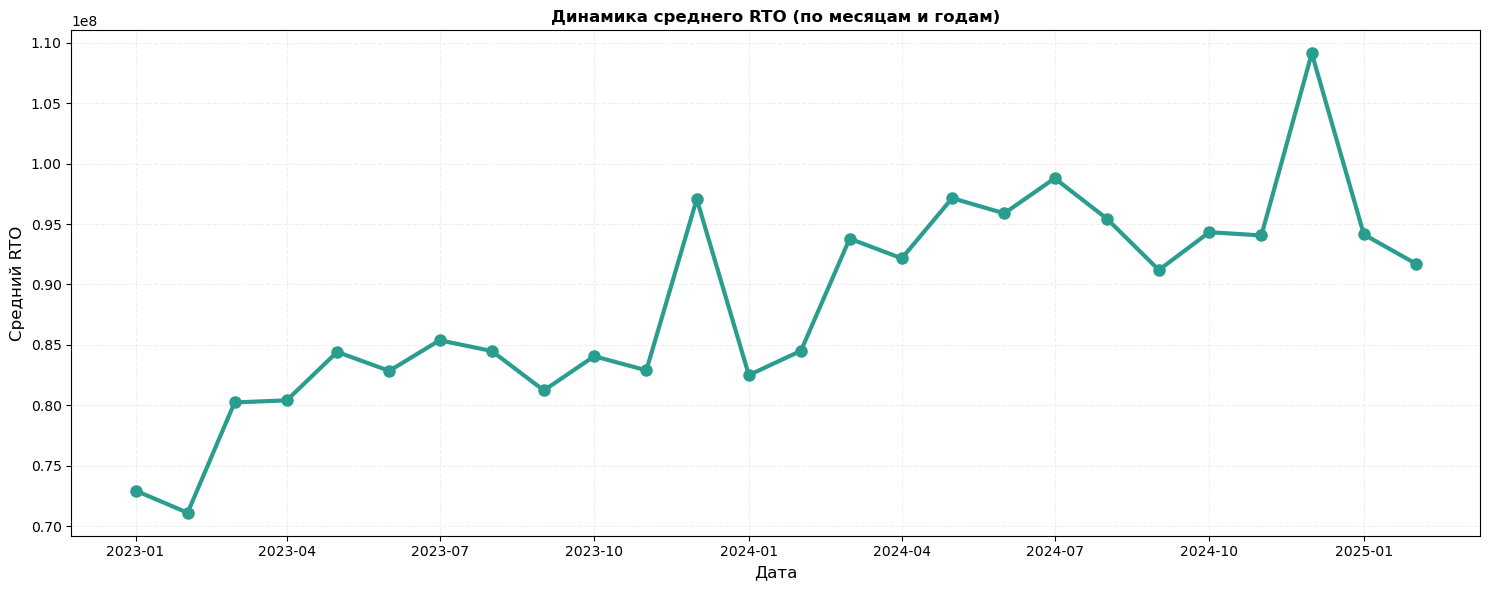

In [82]:
df_groupped = df.groupby(["year", "month"])["rto"].mean().reset_index()
df_groupped["date"] = pd.to_datetime(df_groupped[["year", "month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_groupped["date"], df_groupped["rto"], marker="o", color=palette[1], linewidth=3, markersize=8)
ax.set_title("Динамика среднего RTO (по месяцам и годам)", weight="bold")
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Средний RTO", fontsize=12)
ax.grid(linestyle="--", alpha=0.2)
plt.tight_layout()

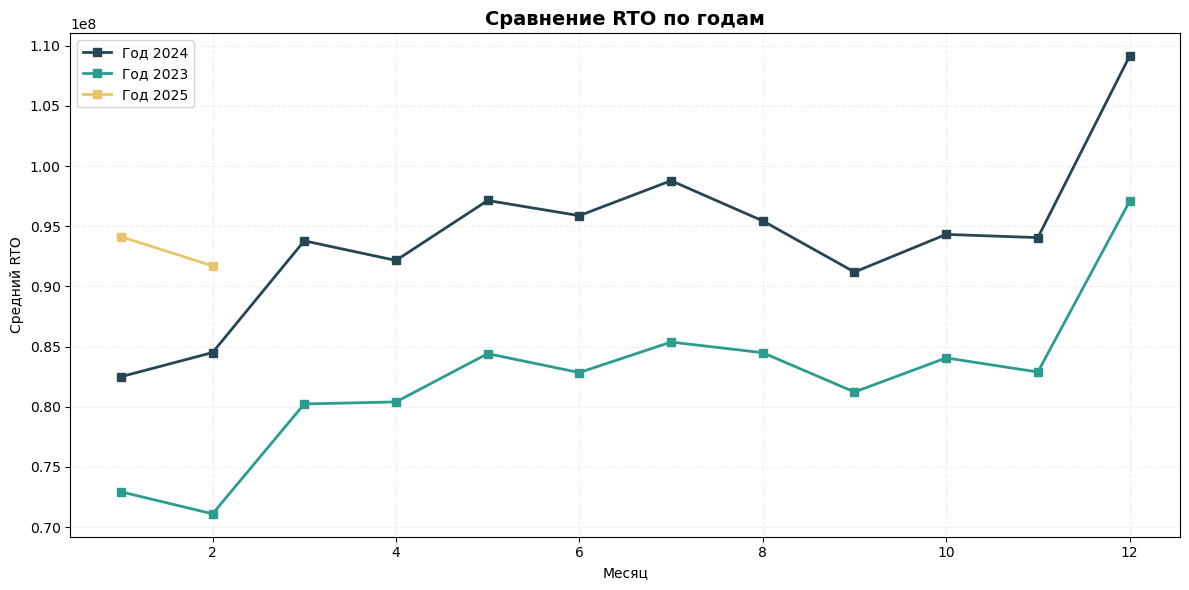

In [83]:
years = df["year"].unique()
fig, ax = plt.subplots(figsize=(12, 6))
for i, year in enumerate(years):
    year_data = df_groupped[df_groupped["year"] == year]
    ax.plot(year_data["month"], year_data["rto"], marker="s", label=f"Год {year}", color=palette[i], linewidth=2)
ax.set_title("Сравнение RTO по годам", weight="bold", fontsize=14)
ax.set_xlabel("Месяц")
ax.set_ylabel("Средний RTO")
ax.grid(linestyle="--", alpha=0.2)
ax.legend()
plt.tight_layout()

In [84]:
from statsmodels.tsa.seasonal import seasonal_decompose
df_groupped = df.groupby(["year", "month"])["rto"].mean().reset_index()
df_groupped["date"] = pd.to_datetime(df_groupped["year"].astype(str) + "-" + df_groupped["month"].astype(str) + "-01")
ts_df = df_groupped.set_index('date')
decomposition = seasonal_decompose(ts_df['rto'], model='additive', period=12)
components = [decomposition.observed, decomposition.trend, decomposition.seasonal, decomposition.resid]
titles = ['Observed', 'Trend', 'Seasonal', 'Residual']

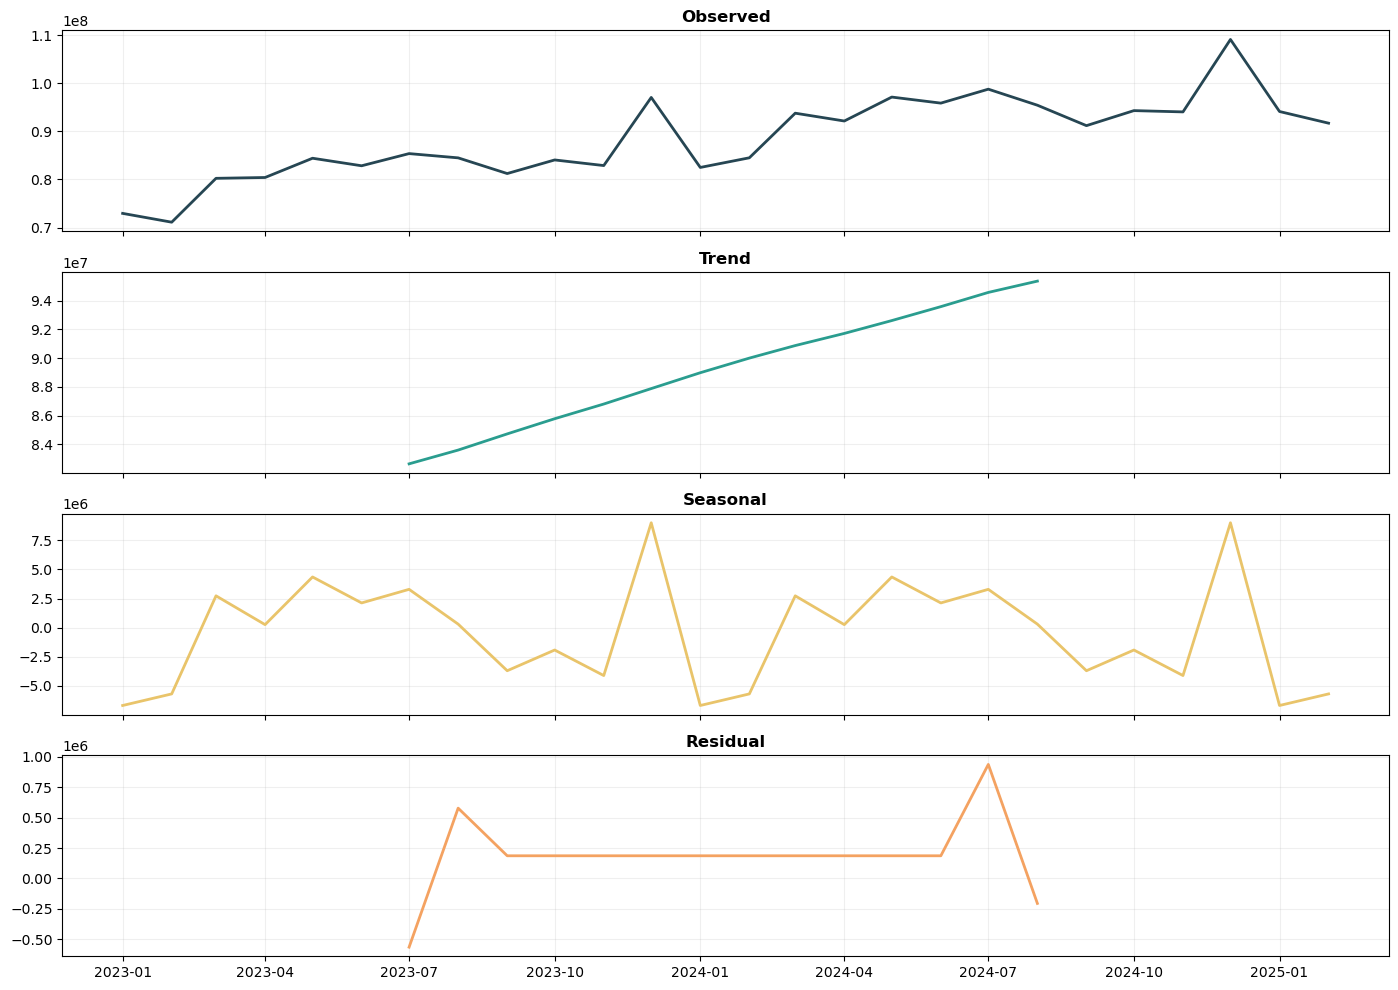

In [85]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10), sharex=True)
for i, data in enumerate(components):
    axes[i].plot(data, color=palette[i], linewidth=2)
    axes[i].set_title(titles[i], weight='bold')
    axes[i].grid(alpha=0.2)
plt.tight_layout()

## Baseline модели

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [87]:
test_interval = df_groupped["date"].tail(2).to_list()
test_interval

[Timestamp('2025-01-01 00:00:00'), Timestamp('2025-02-01 00:00:00')]

Поскольку мы предсказываем будущее (aka значение временного ряда), нельзя делить данные на train и test случайным образом. Т.е. разбиение нужно выполнять последовательно. 

In [88]:
test_mask = (df['year'] == 2025) & (df['month'] == 2)
df_train, df_test = df[~test_mask], df[test_mask]
baseline_means = df_train.groupby('store_id')['rto'].mean()
y_pred_baseline = df_test['store_id'].map(baseline_means).fillna(df_train['rto'].mean())
baseline_avg_res = y_pred_baseline.mean()

Оценим ошибку: 

In [89]:
y_true = df_test['rto']
mape_baseline, score_baseline = get_score(y_true, y_pred_baseline)
print(f'MAE: {mean_absolute_error(y_true, y_pred_baseline)}')
print(f'MAPE: {mape_baseline}%')
print(f'Score: {score_baseline}')
print(f'Среднее предсказание: {baseline_avg_res}')

MAE: 9932744.79499896
MAPE: 11.226021597776816%
Score: 78.80819241358387
Среднее предсказание: 88407655.25826178


### Добавление признаков

In [90]:
df = df.sort_values(by=["store_id", "year", "month"]).reset_index(drop=True)
num_lags = 3
for i in range(num_lags):
    df[f"rto_lag{i + 1}"] = df.groupby("store_id")["rto"].shift(i + 1)
df['rto_rolling_mean_3'] = (
    df.groupby('store_id')['rto']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
df['rto_rolling_mean_6'] = (
    df.groupby('store_id')['rto']
    .transform(lambda x: x.shift(1).rolling(6).mean())
)
df['rto_rolling_std_3'] = (
    df.groupby('store_id')['rto']
    .transform(lambda x: x.shift(1).rolling(3).std())
)
df['rto_trend'] = df['rto_lag1'] - df['rto_lag2']
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [91]:
print(f'Размер датасета до удаления NaN: {df.shape}')
df = df.dropna().reset_index(drop=True)
print(f'Размер датасета после удаления NaN: {df.shape}')

Размер датасета до удаления NaN: (485082, 33)
Размер датасета после удаления NaN: (373140, 33)


In [92]:
test_mask = (df['year'] == 2025) & (df['month'] == 2)

### Ridge регрессия

In [93]:
from sklearn.linear_model import Ridge

**Почему Ridge:** корректно работает с зависимыми признаками. В нашем случае зависимость появляется из-за лаговых полей - нужны из-за временной специфики задачи.

Пересоздадим `X_train`, `X_test`, `y_train`, `y_test` - бали добавлены новые переменные

In [94]:
df_train, df_test = df[~test_mask], df[test_mask]

In [95]:
X_train = df_train.drop("rto", axis=1)
X_test = df_test.drop("rto", axis=1)
y_train = df_train["rto"]
y_test = df_test["rto"]

In [96]:
categorical_features = df.select_dtypes(include="object").columns.tolist()
numeric_features = df.select_dtypes(exclude="object").drop(columns=["rto"]).columns.tolist()
get_stats(df[categorical_features])

C:\Users\Anton\AppData\Local\Temp\ipykernel_28212\2800376526.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include="object").columns.tolist()


,Количество уникальных,Доля,Тип данных
city,3270,0.88,str
region,67,0.02,str
store_area_cat,4,0.00,str
opening_date_cat,3,0.00,str


Выполним кодирование признаков: 
1. Числовые признаки обработаем с помощью `standart_scaler`
2. Категориальные кодируем с помощью [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html), чтобы не усложнять Baseline

In [97]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [98]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
oe.fit(X_train[categorical_features])

X_train_cat = oe.transform(X_train[categorical_features])
X_test_cat = oe.transform(X_test[categorical_features])

In [99]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

Объединяем: 

In [100]:
X_train = np.hstack([X_train_scaled, X_train_cat])
X_test = np.hstack([X_test_scaled, X_test_cat])

In [101]:
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
mape_ridge, score_ridge = get_score(y_test, y_pred_ridge)
ridge_avg_res = y_pred_ridge.mean()
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}')
print(f'MAPE: {mape_ridge:.2f}%')
print(f'Score: {score_ridge:.2f}')
print(f'Среднее предсказание: {ridge_avg_res:.2f}')

MAE: 4307229.41
MAPE: 5.37%
Score: 89.55
Среднее предсказание: 90600060.90


### Случайный лес

In [102]:
from sklearn.ensemble import RandomForestRegressor

In [103]:
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    random_state=41,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [104]:
y_pred_rf = rf_model.predict(X_test)
mape_rf, score_rf = get_score(y_test, y_pred_rf)
rf_avg_res = y_pred_rf.mean()
print(f'MAE: {mean_absolute_error(y_test, y_pred_rf)}')
print(f'MAPE: {mape_rf}%')
print(f'Score: {score_rf}')
print(f'Среднее предсказание: {ridge_avg_res}')

MAE: 5879675.718533241
MAPE: 7.604007784792122%
Score: 85.37019377432755
Среднее предсказание: 90600060.89718431


### Бустинг

In [105]:
from xgboost import XGBRegressor

In [106]:
bst = XGBRegressor(n_estimators=1000, max_depth=10, learning_rate=0.1, objective='reg:squarederror')
bst.fit(X_train, y_train)
y_pred_bst = bst.predict(X_test)
mape_bst, score_bst = get_score(y_test, y_pred_bst)
bst_avg_res = y_pred_bst.mean()
print(f'MAE: {mean_absolute_error(y_test, y_pred_bst)}')
print(f'MAPE: {mape_bst}%')
print(f'Score: {score_bst}')
print(f'Среднее предсказание: {bst_avg_res}')

MAE: 5503412.957619124
MAPE: 6.664534567314276%
Score: 87.11509107536072
Среднее предсказание: 96187960.0


### Результат Baseline

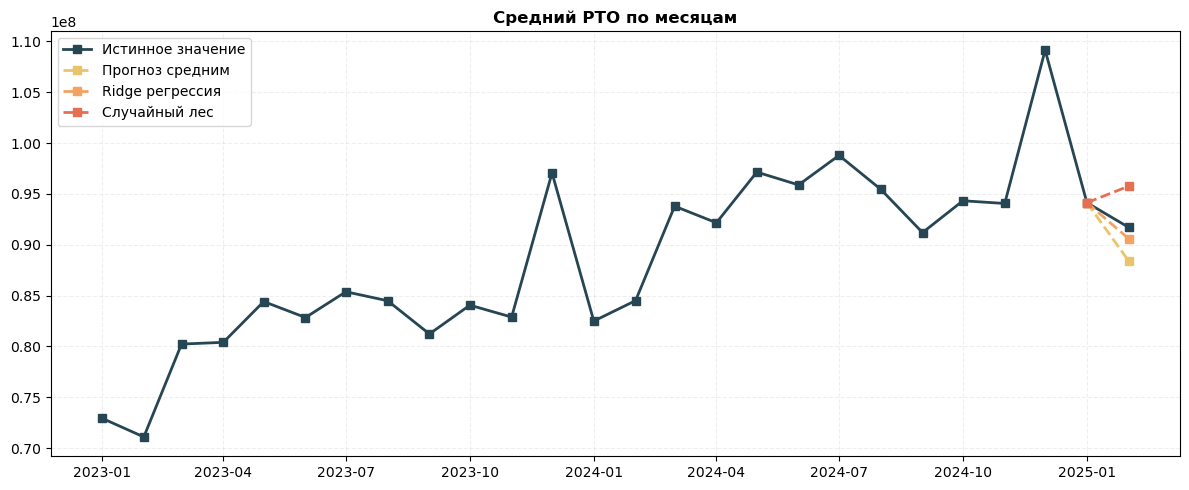

In [107]:
fig, ax = plt.subplots(figsize=(12, 5))

jan_val = df_groupped["rto"].values[-2]
ax.plot(df_groupped["date"], df_groupped["rto"], label="Истинное значение", color=palette[0], linewidth=2, marker="s")
ax.plot(test_interval, [jan_val, baseline_avg_res], linewidth=2, color=palette[2], linestyle="--", marker="s", label="Прогноз средним")
ax.plot(test_interval, [jan_val, ridge_avg_res], linewidth=2, color=palette[3], linestyle="--", marker="s", label="Ridge регрессия")
ax.plot(test_interval, [jan_val, rf_avg_res], linewidth=2, color=palette[4], linestyle="--", marker="s", label="Случайный лес")
ax.legend()
ax.grid(linestyle="--", alpha=0.2)
ax.set_title("Средний РТО по месяцам", weight="bold")
plt.tight_layout()